> This script is deigned to be used with conda env
> crime_weather_env

Code to explore the crimetology_NS.parquet file.
Data created via combine_crime_ceda_data.py.

Good background reading available at [GeoffBoeing.com](https://geoffboeing.com/2014/08/clustering-to-reduce-spatial-data-set-size/)

Optimisation of data processing required as 1.5 million data rows to be clustered with only 16GB of RAM. 

## Import modules

In [ ]:
# standard libraries
import os
from pathlib import Path

# other libraries
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

# typers and submodules
from duckdb import DuckDBPyConnection
from matplotlib.colors import LogNorm
from pandas import DataFrame
from pyproj import Transformer
from sklearn.cluster import DBSCAN

## Directories, db and Path Setup

In [2]:
cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / 'data' / 'police_archives'
crime_db: Path = data_dir/'crime_archive.db'

Connect to the duckdb

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

Introspect

In [4]:
# introspect
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [5]:
con.execute(query="SELECT * FROM crimetology_NS_clean LIMIT 5;").df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347


In [6]:
## expect this to be 1255500
con.execute(query="SELECT COUNT(*) FROM crimetology_NS_clean LIMIT 5;").df()

,count_star()
0,1255500


In [7]:
con.execute(query="DESCRIBE crimetology_NS_clean").df()

,column_name,column_type,null,key,default,extra
0,Crime ID,VARCHAR,YES,None,None,None
1,Month,VARCHAR,YES,None,None,None
2,Longitude,DOUBLE,YES,None,None,None
3,Latitude,DOUBLE,YES,None,None,None
4,Crime type,VARCHAR,YES,None,None,None
5,tasmax,FLOAT,YES,None,None,None
6,tas,FLOAT,YES,None,None,None
7,groundfrost,FLOAT,YES,None,None,None
8,sun,FLOAT,YES,None,None,None
9,snowLying,FLOAT,YES,None,None,None


In [8]:
con.execute(query="SUMMARIZE crimetology_NS_clean").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,Crime ID,VARCHAR,000006a0d6919a710d3bd0a37d0ff31a0eb99ee5a1c20f...,fffff37e0363180e0780c2208d545e512d90e3de540bd8...,1622925,None,None,None,None,None,1255500,0.0
1,Month,VARCHAR,2016-01,2025-12,136,None,None,None,None,None,1255500,0.0
2,Longitude,DOUBLE,0.300512,1.757943,42131,1.1395494182150399,0.3959295100528411,0.8500513823095001,1.1944388974471967,1.331359820752464,1255500,0.0
3,Latitude,DOUBLE,51.950135,52.972354,52334,52.4397646439887,0.26507872988828846,52.18013301436883,52.5255513029674,52.63645741113791,1255500,0.0
4,Crime type,VARCHAR,Anti-social behaviour,Violence and sexual offences,16,None,None,None,None,None,1255500,0.0
5,tasmax,FLOAT,4.8080764,27.462076,156283,15.435893627845449,5.682904224237647,10.254743939489043,15.083648437823127,20.639694969578372,1255500,0.0
6,tas,FLOAT,2.1268184,20.685835,149424,11.429114954629394,4.8998097611869325,6.925210030585593,11.248591030747138,15.957389362168586,1255500,0.0
7,groundfrost,FLOAT,0.0,26.692324,144181,6.5048300714746805,6.642106525202314,0.04444239002625879,4.231915705034112,12.278067579969555,1255500,0.0
8,sun,FLOAT,16.014242,328.6736,213372,149.59287266437983,70.84050654222102,83.60420121738001,155.07737901819073,204.69417393090228,1255500,0.0
9,snowLying,FLOAT,0.0,7.6520123,67539,0.2088989479030356,0.7101793982724235,0.0,0.0,0.03728017438487241,1255500,0.0


The above introspection all looks good

## Prepare data for DBScan

(Reduce dimensionality)

Isolate columns needed for clustering

In [9]:
features_query = """ SELECT "Crime ID",
                             Latitude,
                             Longitude
                     FROM crimetology_NS_clean
                 """
features_df: DataFrame= con.execute(query=features_query).df()

In [10]:
features_df

,Crime ID,Latitude,Longitude
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191
...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171


HDBScan can be run with metric=havesine, but due to the size of data here I cannot naively run the clustering on the entire 1.5 million rows with the lat/lon method. Switch to euclidean methods so I can take advantage of the sample_weight method to reduce the data dimensionality. 

Transform from latitude/longitude to British National Grid (meters), then create spatial weighting on square areas of events instead of point by point clustering which is very memory heavy. 

In [11]:
### pyproj transformer
# need to be careful about x and y directions
transformer: Transformer = Transformer.from_crs(crs_from="EPSG:4326", crs_to="EPSG:27700", always_xy=True)


In [12]:
features_df['x_m'], features_df['y_m'] = transformer.transform(xx=features_df['Longitude'].values, yy=features_df['Latitude'].values)

In [13]:
features_df

,Crime ID,Latitude,Longitude,x_m,y_m
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596,571858.249237,274959.005787
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665,618774.001407,242942.326342
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886,563459.181881,263559.242217
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570,583997.126720,265750.109761
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191,629208.018156,234946.350104
...,...,...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594,617790.267388,282209.633966
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691,611018.161022,279776.733228
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864,610896.210752,279715.810269
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171,610974.178155,279975.803697


In [14]:
## now bin to start reducing dimensionality
# put each easting and northing in a 50m box
# 
grid_width = 50  
features_df['grid_x'] = (features_df['x_m'] // grid_width).astype(np.int32)
features_df['grid_y'] = (features_df['y_m'] // grid_width).astype(np.int32)

In [15]:
features_df

,Crime ID,Latitude,Longitude,x_m,y_m,grid_x,grid_y
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596,571858.249237,274959.005787,11437,5499
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665,618774.001407,242942.326342,12375,4858
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886,563459.181881,263559.242217,11269,5271
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570,583997.126720,265750.109761,11679,5315
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191,629208.018156,234946.350104,12584,4698
...,...,...,...,...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594,617790.267388,282209.633966,12355,5644
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691,611018.161022,279776.733228,12220,5595
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864,610896.210752,279715.810269,12217,5594
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171,610974.178155,279975.803697,12219,5599


In [ ]:
## now generate sample size per grid box (i.e. how many events are present per grid box)
grid_df: DataFrame = features_df.groupby(by=['grid_x', 'grid_y']).size().reset_index(name='point_count')

In [17]:
grid_df

,grid_x,grid_y,point_count
0,11110,6359,1
1,11110,6435,7
2,11112,6359,9
3,11112,6408,31
4,11113,6360,1
...,...,...,...
37414,13102,5882,157
37415,13103,5885,95
37416,13103,5886,258
37417,13103,5894,27


This method has reduced the dimensionality from:

Point by point data: (1255500 x 2) = 2,511,000 
Gridded data: (37419 x 3) = 112,257

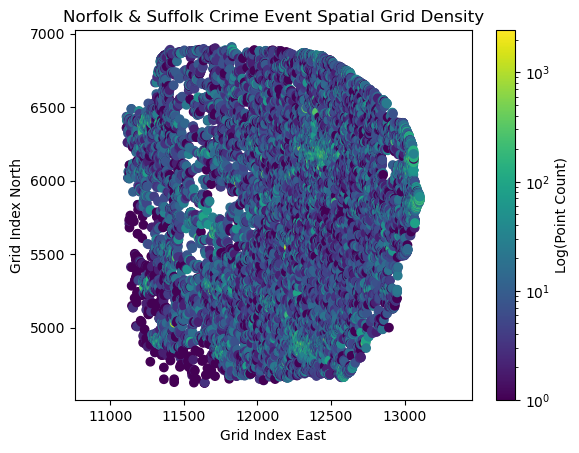

In [18]:
plt.scatter(x=grid_df['grid_x'],y=grid_df['grid_y'],c=grid_df['point_count'],cmap='viridis',norm=LogNorm())
plt.colorbar(label='Log(Point Count)')
plt.title(label='Norfolk & Suffolk Crime Event Spatial Grid Density')
plt.xlabel(xlabel='Grid Index East')
plt.ylabel(ylabel='Grid Index North')
plt.axis('equal')  # Keeps true geographic proportions
plt.show()

## Apply efficient DBSCan method

User defined metrics - opting for smaller clusters as leisure zones could includes parks and retail zone could be just a few shops on a smaller highstreet. 

In [19]:
# define epsilon in grid index (50m box edge)
# e.g 5 = maximum 5*50m = 250m radius for a zone
epsilon: float = 3

#definte minimum grid points to form a cluster
# each grid box is non-zero if a crime
# event has occuring within it within the last 10yrs
min_samples_in: int = 2

Set up weighted DBScan method

In [20]:
clusterer = DBSCAN(eps=epsilon,
                   min_samples=min_samples_in,
                   metric='euclidean')                 

Apply clustering to data

In [21]:
grid_df['cluster_id']= clusterer.fit_predict(X=grid_df[['grid_x', 'grid_y']], sample_weight=grid_df['point_count'])

In [22]:
grid_df

,grid_x,grid_y,point_count,cluster_id
0,11110,6359,1,0
1,11110,6435,7,1
2,11112,6359,9,0
3,11112,6408,31,2
4,11113,6360,1,0
...,...,...,...,...
37414,13102,5882,157,9025
37415,13103,5885,95,9197
37416,13103,5886,258,9197
37417,13103,5894,27,9198


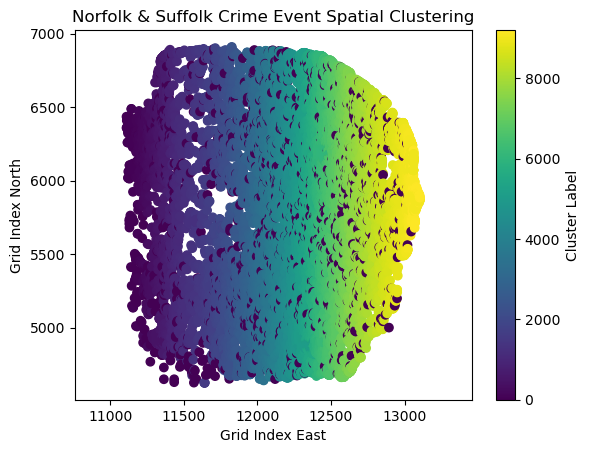

In [23]:
plt.scatter(x=grid_df['grid_x'],y=grid_df['grid_y'],c=grid_df['cluster_id'],cmap='viridis')
plt.colorbar(label='Cluster Label')
plt.title(label='Norfolk & Suffolk Crime Event Spatial Clustering')
plt.xlabel(xlabel='Grid Index East')
plt.ylabel(ylabel='Grid Index North')
plt.axis('equal')  # Keeps true geographic proportions
plt.show()

## Map back to point by point data & Have a look

In [24]:
features_df: DataFrame = features_df.merge(right=grid_df[['grid_x', 'grid_y', 'cluster_id']], on=['grid_x', 'grid_y'], how='left')

In [25]:
features_df

,Crime ID,Latitude,Longitude,x_m,y_m,grid_x,grid_y,cluster_id
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,52.345789,0.521596,571858.249237,274959.005787,11437,5499,869
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,52.041702,1.188665,618774.001407,242942.326342,12375,4858,5065
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,52.245956,0.392886,563459.181881,263559.242217,11269,5271,289
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,52.259155,0.694570,583997.126720,265750.109761,11679,5315,1703
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,51.965723,1.335191,629208.018156,234946.350104,12584,4698,7123
...,...,...,...,...,...,...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,52.394576,1.199594,617790.267388,282209.633966,12355,5644,5567
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,52.375385,1.098691,611018.161022,279776.733228,12220,5595,4580
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,52.374885,1.096864,610896.210752,279715.810269,12217,5594,4580
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,52.377189,1.098171,610974.178155,279975.803697,12219,5599,4580


Do a quick test plot to have a look at clustering output

In [27]:
## plotly cant cope with original data size. 
test_map: DataFrame = features_df.groupby(by="cluster_id").agg(lat=("Latitude", 'mean'),lon=("Longitude", 'mean'),point_count=("cluster_id", 'count')).reset_index()

In [28]:
test_map

,cluster_id,lat,lon,point_count
0,-1,52.454135,1.020522,1113
1,0,52.737256,0.303767,11
2,1,52.771041,0.303858,7
3,2,52.758894,0.304464,31
4,3,52.763219,0.306282,572
...,...,...,...,...
9196,9195,52.495854,1.754783,102
9197,9196,52.471815,1.752932,13
9198,9197,52.486912,1.757203,353
9199,9198,52.490593,1.757123,27


In [32]:
fig = px.scatter_map(data_frame=test_map,
                            lat='lat',
                            lon='lon',
                            size='point_count',
                            hover_name='cluster_id',
                            zoom=7,
                            size_max=50,
                            title='Norfolk and Suffolk Crime Location Cluster Mapping (2015-2025)')
                            
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.update_yaxes(scaleanchor="x",scaleratio=1)
fig.update_layout(width=800, height=800)

fig.show()

In [36]:
# overwrite fig object to stop memory crashes
fig=None

Have a look at just one cluster for idea of shape

In [61]:
single_cluster_plot: DataFrame = features_df.where(cond=features_df['cluster_id']==286).dropna()
single_cluster_plot: DataFrame = single_cluster_plot.groupby(by=["Latitude","Longitude"]).agg(func='count').reset_index()[["Latitude","Longitude","Crime ID"]]

fig = px.scatter_map(data_frame=single_cluster_plot,
                            lat='Latitude',
                            lon='Longitude',
                            size='Crime ID',
                            zoom=15,
                            size_max=60,
                            title='One cluster Check [286] (2015-2025)')
                            
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.update_yaxes(scaleanchor="x",scaleratio=1)
fig.update_layout(width=800, height=800)


fig.show()

## Updated Database with clustering lables

In [62]:
cluster_lables_df: DataFrame = features_df[['Crime ID','cluster_id']]
cluster_lables_df

,Crime ID,cluster_id
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,869
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,5065
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,289
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,1703
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,7123
...,...,...
1255495,b0817e29e4812387eefd4dbf61223703bd4b2ae18e659e...,5567
1255496,40f5d31aebde7ecbbb3301ba6f48d58a9fc95fdb77fb2c...,4580
1255497,bbf00daaa7f12ee2fbff2328b9065555c668f05798d94f...,4580
1255498,debbfd614bade093a6a6782521caae560f6a5f0565f427...,4580


In [63]:
con.register(view_name="clustered_df", python_object=cluster_lables_df)

In [73]:
con.execute(query="""SELECT * FROM clustered_df LIMIT 5;""").df()

,Crime ID,cluster_id
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,869
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,5065
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,289
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,1703
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,7123


In [75]:
con.execute(query="""ALTER TABLE crimetology_NS_clean ADD COLUMN IF NOT EXISTS "Cluster ID" INTEGER;""")

In [76]:
add_cluster_labels_query = """
                           UPDATE crimetology_NS_clean
                           SET "Cluster ID" = clustered_df.cluster_id
                           FROM clustered_df
                           WHERE  crimetology_NS_clean."Crime ID" = clustered_df."Crime ID"
                           """

In [77]:
con.execute(query="BEGIN TRANSACTION;")
con.execute(query=add_cluster_labels_query)

In [80]:
con.execute(query="""SELECT * FROM crimetology_NS_clean LIMIT 5;""").df()

,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702,289
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696,1703
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347,7123


In [81]:
#con.execute(query="ROLLBACK;")
#All looks good
con.close()